In [1]:
from pathlib import Path
import sys
import warnings
import os
import gc
from copy import deepcopy

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision.ops import MLP
import torch.optim as optim
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold, StratifiedKFold
from torch.utils.data import Dataset, TensorDataset, DataLoader, Subset
import optuna
import joblib
from optuna.samplers import TPESampler

import random
import math
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import scanpy as sc
import seaborn as sns
import anndata
from anndata import AnnData
import pickle

sys.path.insert(0, "../../")

import scgpt as scg
from scgpt.tokenizer import GeneVocab
from scgpt import logger

warnings.filterwarnings("ignore", category=ResourceWarning)

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)
    
seed = 13
seed_everything(seed)

/home/harshil.sharma/miniconda3/envs/gene2ephys/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/allen/programs/mindscope/workgroups/auto-model/harshil.sharma/TransformerEphysPrediction/Human/onefeaturepermlp/../../scgpt/model/model.py:21: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/allen/programs/mindscope/workgroups/auto-model/harshil.sharma/TransformerEphysPrediction/Human/onefeaturepermlp/../../scgpt/model/multiomic_model.py:19: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")


In [2]:
cell_embeddings_adata = anndata.read_h5ad("../Data Preprocessing/cell_embeddings_adata.h5ad")
combined_ephys_df = pd.read_pickle("../Data Preprocessing/combined_ephys_df.pkl")

with open('onefeaturepermlp_results.pkl', 'rb') as f:
    results = pickle.load(f)
shuffled_cell_indices = np.load('onefeaturepermlp_shuffled_cell_indices.npy')
ephys_truth = np.load('onefeaturepermlp_ephys_truth.npy')

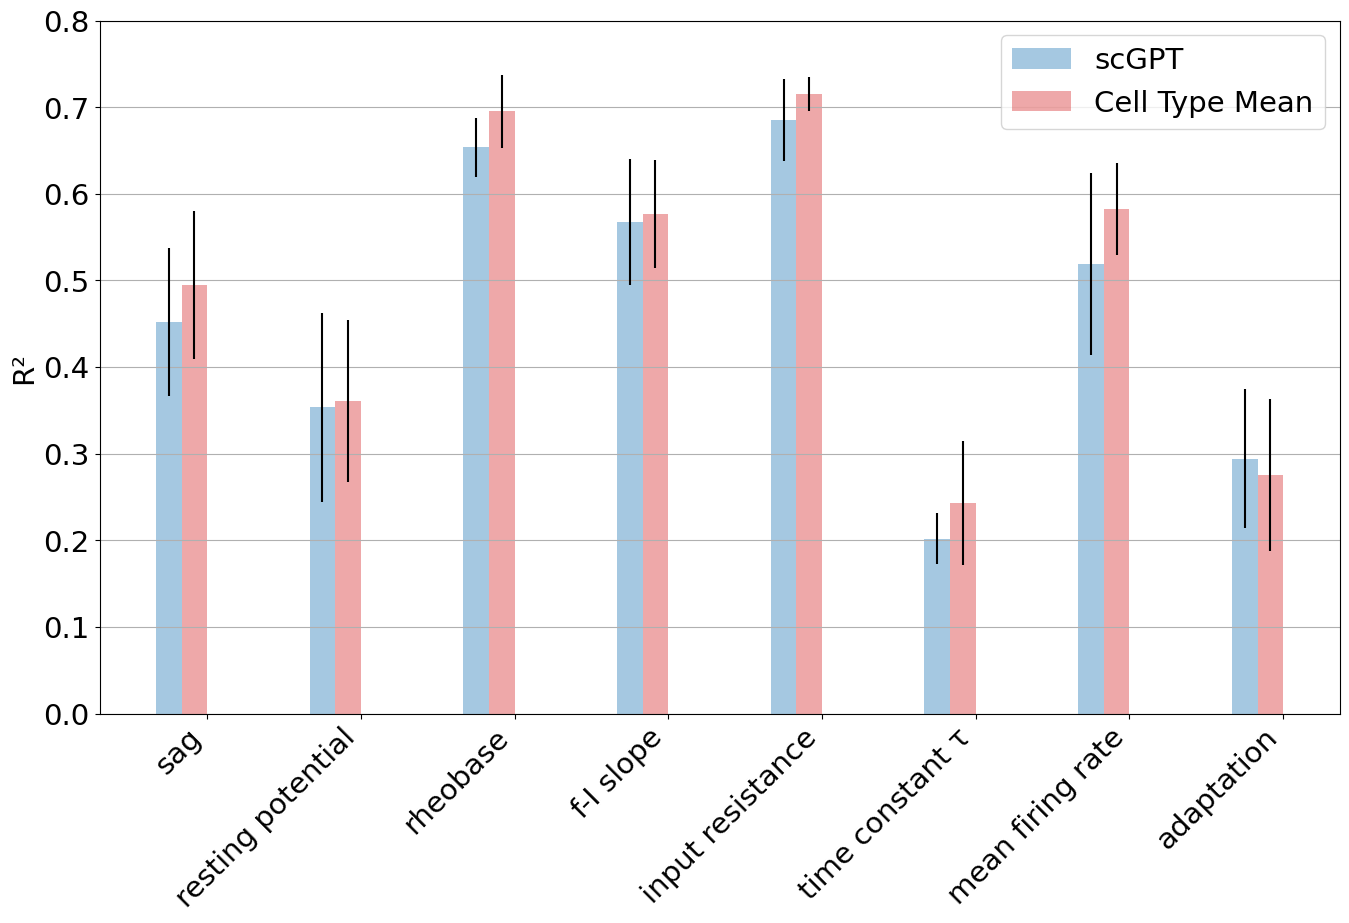

In [3]:
labels = ["scGPT", "Cell Type Mean"]
data = []
errors = []
scgptdata = []
scgpterrors = []
feature_names = [col for col in combined_ephys_df.columns if col != "SpecimenID"]

for feature in feature_names:
    # r2_scores is (number of outer folds)x(number of epochs)x(number of ephys features)
    scgptdata.append(np.mean(results[feature]["r2_scores"].squeeze()[:,-1], axis=0))
    scgpterrors.append(np.std(results[feature]["r2_scores"].squeeze()[:,-1], axis=0))

scgptdata = np.array(scgptdata)
data.append(scgptdata)
data.append(np.mean(results["cell type mean"]["r2_scores"], axis=0))
scgpterrors = np.array(scgpterrors)
errors.append(scgpterrors)
errors.append(np.std(results["cell type mean"]["r2_scores"], axis=0))

x = np.arange(8)*1.2  # the label locations
width = 0.2  # the width of the bars
multiplier = 0

colors = ["C0", "C3"]
plt.rcParams.update({'font.size': 21})
fig, ax = plt.subplots(figsize=(16, 9))
for group_label, group_data, group_error, c in zip(labels, data, errors, colors):
    offset = width * multiplier
    rects = ax.bar(x + offset, group_data, width, label=group_label, alpha=0.4, yerr=group_error, color=c)
    multiplier += 1

feature_names = [col for col in combined_ephys_df.columns if col != "SpecimenID"]
feature_names[1] = "resting potential"
ax.set_xticks(x + width*1.5, feature_names, rotation=45, ha="right")
plt.ylim(0, 0.8)
ax.set_ylabel("R²")
ax.legend()
ax.yaxis.grid(True)

plt.savefig("Figures/singleoutputtest.pdf", bbox_inches="tight")
plt.show()